# Inspecting the Exoplanet Preprocessing Pipeline

This notebook demonstrates how to load, preprocess, and inspect exoplanet data using the LifeFinder's pipeline.

In [1]:
# Set up the Python path if running from the notebook directory
import sys
import os
sys.path.append(os.path.abspath("../.."))

In [2]:
# Import necessary modules
from lifefinder.data.nasa_client import NasaExoplanetClient
from lifefinder.data.preprocessor import build_exoplanet_pipeline
import pandas as pd
import numpy as np

## Fetch Raw Exoplanet Data

In [3]:
client = NasaExoplanetClient()
raw_df = client.fetch_exoplanets(limit=1000)
print(f"Raw data shape: {raw_df.shape}")
raw_df.head()

2025-10-03 06:00:40,364 |     INFO | nasa_client | Requesting NASA Exoplanet Archive: https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+top+1000+pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_orbper,pl_orbsmax,pl_rade,pl_radj,pl_bmasse,pl_bmassj,pl_dens,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,st_spectype,sy_dist,rastr,decstr+from+ps&format=csv
2025-10-03 06:00:42,403 |     INFO | nasa_client | Saved exoplanet CSV to exoplanets.csv
Raw data shape: (1000, 26)


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_orbper,pl_orbsmax,pl_rade,...,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,st_spectype,sy_dist,rastr,decstr
0,HD 70642 b,HD 70642,1,1,Radial Velocity,2003,Anglo-Australian Telescope,2124.540000,3.3180,NaN,...,NaN,5732.0,0.98400,1.078,0.22,4.45800,NaN,29.2760,08h21m27.87s,-39d42m16.00s
1,Kepler-20 d,Kepler-20,2,6,Transit,2011,Kepler,77.611840,0.3453,2.75,...,369.0,5455.0,0.94400,0.912,0.01,4.40000,NaN,282.5630,19h10m47.52s,+42d20m18.88s
2,Kepler-976 b,Kepler-976,1,1,Transit,2016,Kepler,105.956415,0.4209,3.81,...,322.0,5308.0,0.79600,0.887,0.02,4.58300,NaN,1012.4100,19h19m28.71s,+46d43m46.87s
3,Kepler-188 c,Kepler-188,1,2,Transit,2014,Kepler,5.996537,NaN,NaN,...,NaN,5704.0,1.06544,1.020,NaN,4.39161,NaN,968.5440,18h45m07.13s,+44d18m55.71s
4,K2-151 b,K2-151,2,1,Transit,2018,K2,3.835376,NaN,1.50,...,NaN,NaN,0.45000,NaN,NaN,NaN,NaN,69.4798,01h17m13.15s,+09d30m04.56s


## Build and Apply the Preprocessing Pipeline

In [4]:
pipeline = build_exoplanet_pipeline()
processed_array = pipeline.fit_transform(raw_df)
print(f"Processed data shape: {processed_array.shape}")

Processed data shape: (468, 67)


/usr/local/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Inspect the Processed Output

In [5]:
# If the pipeline outputs a numpy array, convert to DataFrame for inspection
import scipy.sparse

if isinstance(processed_array, np.ndarray):
    processed_df = pd.DataFrame(processed_array)
elif scipy.sparse.issparse(processed_array):
    processed_df = pd.DataFrame(processed_array.toarray())
else:
    processed_df = processed_array
processed_df.head()

,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,66
0,-0.261712,-0.668973,-2.451217,-0.446308,-0.673086,0.040945,0.040943,-0.225990,-0.225906,-0.354777,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.261712,-0.668973,-1.837921,-0.415474,-0.571619,0.030962,0.030960,-0.265052,-0.264972,-0.354916,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.261712,-0.668973,-1.531274,-0.393500,-0.505246,0.005621,0.005619,-0.020232,-0.020128,-0.350538,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.261712,-0.668973,-2.144569,-0.273855,-0.220681,0.016832,0.016831,0.066573,0.066685,-0.351483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.261712,0.978813,-2.144569,-0.461627,-0.740985,-0.061197,-0.061189,-0.397015,-0.396960,-0.345310,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Visualize Feature Distributions

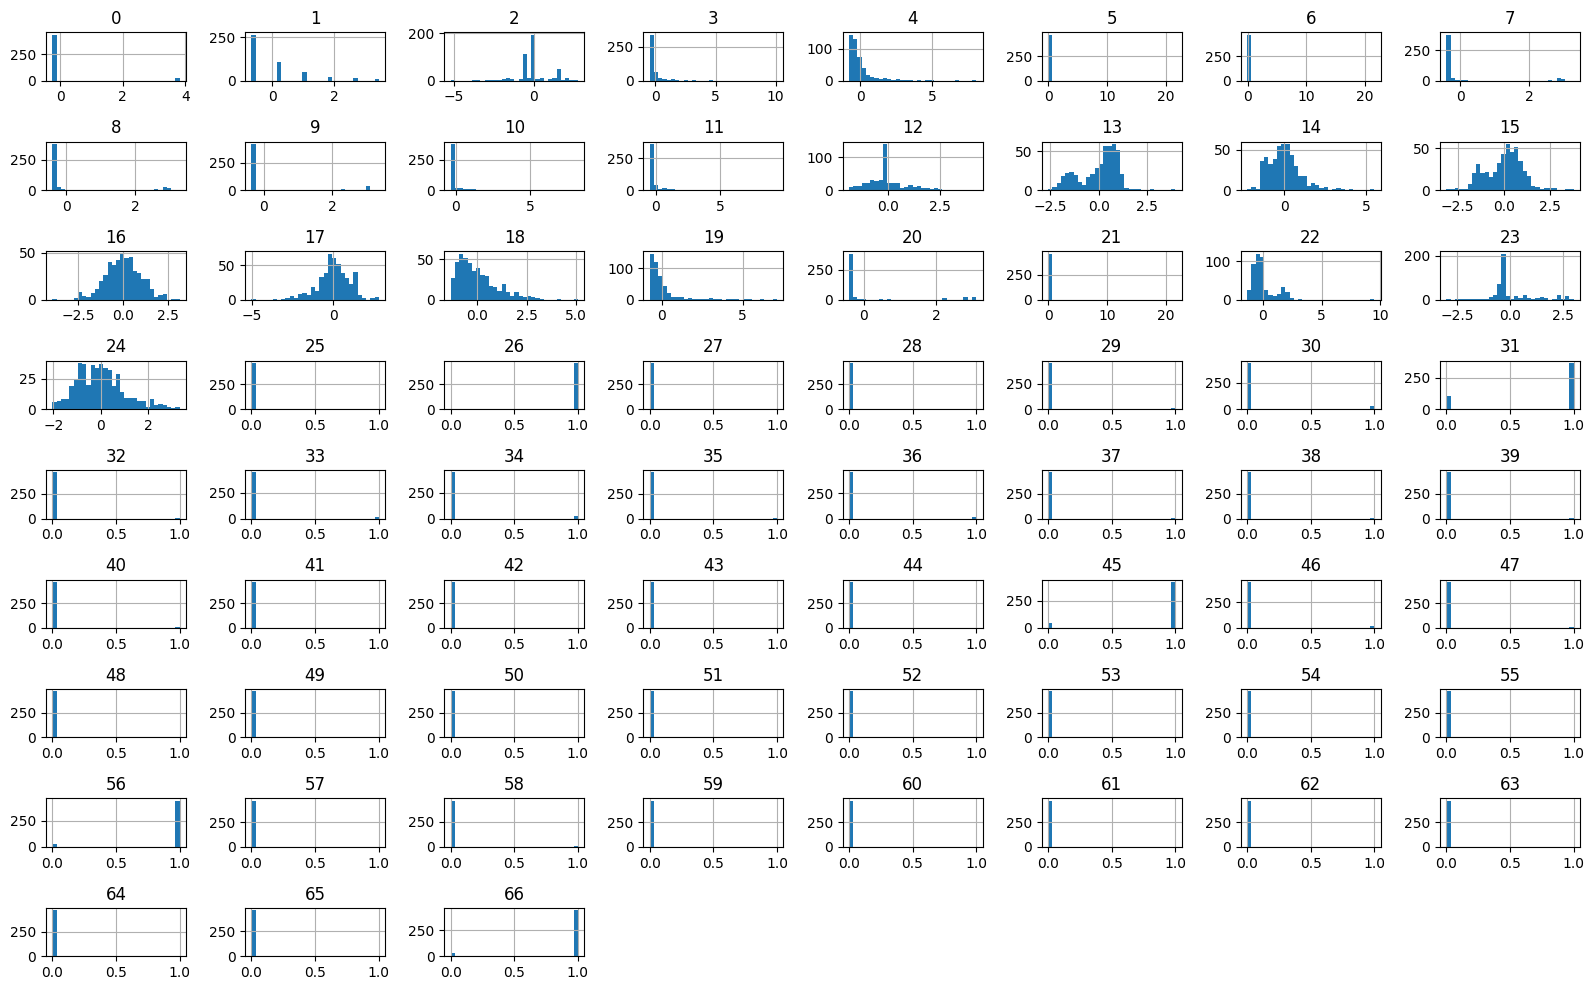

In [6]:
import matplotlib.pyplot as plt
processed_df.hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()